# **10x Visium colon metabolic zonation robustness analysis**

In [1]:
import harreman
import os
import json
import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import zscore
from plotnine import *
import gseapy
import warnings
warnings.filterwarnings("ignore")

SIGNATURES_PATH = '/home/projects/nyosef/oier/Harreman_files/signatures'

## Visium colon dataset

In [2]:
BASE_PATH = "/home/projects/nyosef/oier/Harreman_files/Visium_colon"
ADATA_PATH = os.path.join(BASE_PATH, 'h5ads')
DATA_PATH = os.path.join(BASE_PATH, 'data')
PLOTS_PATH = os.path.join(BASE_PATH, 'plots')

In [3]:
with open(os.path.join(SIGNATURES_PATH, 'KEGG_metab_m.json')) as json_file:
    kegg_metab = json.load(json_file)

In [4]:
adata = ad.read_h5ad(os.path.join(ADATA_PATH, 'Visium_colon_unrolled_adata.h5ad'))

Filter out genes expressed in less than 50 spots per sample

In [5]:
sample_col = 'cond'
n_genes_expr = 50
genes_to_keep = np.zeros(adata.shape[1], dtype=bool)

for sample in adata.obs[sample_col].unique():
    adata_sample = adata[adata.obs[sample_col] == sample]
    expressed = np.array((adata_sample.X > 0).sum(axis=0)).flatten()
    genes_to_keep |= expressed >= n_genes_expr

adata = adata[:, genes_to_keep]

### Pairwise correlation (number of neighbors)

In [6]:
n_neighbors_values = [5, 10, 15, 20, 25, 30, 35, 40, 45, 50]

In [7]:
def Enrichment_analysis_pipeline(gene_set_m, genes, background):
    enr = gseapy.enrichr(gene_list=genes,
                        gene_sets=gene_set_m,
                        organism='mouse',
                        outdir=None,
                        background=background
                        )

    if enr.results.shape[0] == 0:
        return

    enr_results = enr.results.set_index('Term')

    return enr_results

In [8]:
def pairwise_correlation_n_neighbors_robustness_pipeline(adata, n_neighbors):
    
    harreman.tl.compute_knn_graph(adata,
                           compute_neighbors_on_key="spatial_unrolled",
                           n_neighbors=n_neighbors,
                           weighted_graph=False,
                           sample_key='cond')
        
    harreman.hs.compute_local_autocorrelation(adata, layer_key="counts", model='danb', species='mouse', use_metabolic_genes=True)
    
    gene_autocorrelation_results = adata.uns['gene_autocorrelation_results']
    genes = gene_autocorrelation_results.loc[gene_autocorrelation_results.Z_FDR < 0.01].sort_values('Z', ascending=False).index
    
    harreman.hs.compute_local_correlation(adata, genes=genes)
    
    harreman.hs.create_modules(adata, min_gene_threshold=20)
    
    harreman.hs.calculate_module_scores(adata)
    
    modules = adata.obsm['module_scores'].columns
    module_scores_z = pd.DataFrame(zscore(adata.obsm['module_scores']), index=adata.obsm['module_scores'].index, columns=modules)
    morans = {
        m: sc.metrics.morans_i(adata.obsp['weights'], vals=module_scores_z[m])
        for m in modules
    }
    morans_df = pd.Series(morans)
    
    gene_modules = adata.uns['gene_modules']
    
    n_sig_pathways = {}
    for module, genes in gene_modules.items():
        enr_results = Enrichment_analysis_pipeline(kegg_metab, genes, gene_autocorrelation_results.index.tolist())
        enr_results = enr_results[enr_results['Adjusted P-value'] < 0.05].sort_values('Combined Score', ascending=False).copy()
        n_sig_pathways[module] = enr_results.shape[0]
    n_sig_pathways_df = pd.Series(n_sig_pathways)
    
    return morans_df, n_sig_pathways_df

In [9]:
pairwise_correlation_n_neighbors_morans_i_dict = {}
pairwise_correlation_n_neighbors_n_sig_pathways_dict = {}
for n_neighbors in n_neighbors_values:
    print(n_neighbors)
    morans_df, n_sig_pathways_df = pairwise_correlation_n_neighbors_robustness_pipeline(adata, n_neighbors)
    pairwise_correlation_n_neighbors_morans_i_dict[n_neighbors] = morans_df
    pairwise_correlation_n_neighbors_n_sig_pathways_dict[n_neighbors] = n_sig_pathways_df

5


100%|██████████| 10/10 [00:01<00:00,  7.84it/s]


10


100%|██████████| 8/8 [00:01<00:00,  7.26it/s]


15


...

100%|██████████| 10/10 [00:02<00:00,  3.78it/s]


45


100%|██████████| 9/9 [00:01<00:00,  4.89it/s]


50


100%|██████████| 10/10 [00:02<00:00,  4.00it/s]


In [10]:
morans_df = pd.concat(
    {key: series for key, series in pairwise_correlation_n_neighbors_morans_i_dict.items()}, axis=1
).melt( 
    var_name="n_neighbors", 
    value_name="Value"
).dropna()

n_sig_pathways_df = pd.concat(
    {key: series for key, series in pairwise_correlation_n_neighbors_n_sig_pathways_dict.items()}, axis=1
).melt( 
    var_name="n_neighbors", 
    value_name="Value"
).dropna()

In [11]:
morans_df["n_neighbors"] = morans_df["n_neighbors"].astype('category')
n_sig_pathways_df["n_neighbors"] = n_sig_pathways_df["n_neighbors"].astype('category')

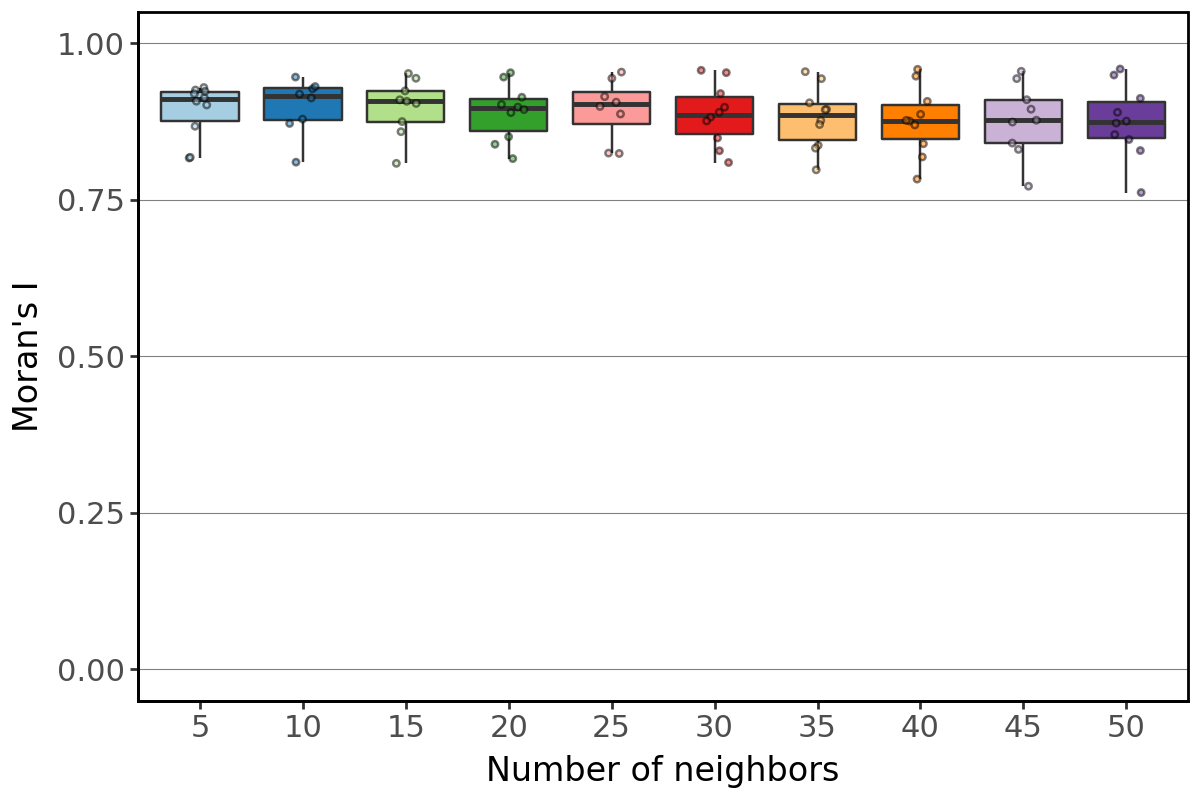

In [12]:
fig = (
ggplot(data=morans_df, mapping=aes(x="n_neighbors", y="Value", fill="n_neighbors")) 
+ geom_boxplot(position=position_dodge(width=0.8), outlier_shape="")
+ geom_jitter(width = 0.15, height=0, size=0.8, alpha=0.5)
+ scale_fill_manual(values=["#A6CEE3", "#1F78B4", "#B2DF8A", "#33A02C", "#FB9A99", "#E31A1C", "#FDBF6F", "#FF7F00", "#CAB2D6", "#6A3D9A"])
+ xlab('Number of neighbors')
+ ylab("Moran's I")
+ theme_classic() 
+ scale_y_continuous(
        limits=(0, 1),
        breaks=[0, 0.25, 0.5, 0.75, 1]
)
+ theme(panel_grid_major_y=element_line(color="grey", size=0.4),
        panel_grid_minor_y=element_blank(),
        plot_title = element_text(hjust = 0.5,
                                margin={"t": 0, "b": 5, "l": 0, "r": 0},
                                size = 14,
                                face='bold'),
        legend_position = "none",
        axis_title_x = element_text(size = 12),
        axis_title_y = element_text(size = 12),
        axis_text_x = element_text(margin={"t": 4, "b": 0, "l": 10, "r": 0}, size = 11),
        axis_text_y = element_text(margin={"t": 0, "b": 0, "l": 0, "r": 4}, size = 11),
        panel_border = element_rect(color='black'),
        panel_background = element_rect(colour = "black",
                                        linewidth = 1),
        figure_size=(6, 4))
)
fig.save(os.path.join(PLOTS_PATH, 'pairwise_cor_morans_i_n_neighbors_box_plot.svg'), format='svg')
fig

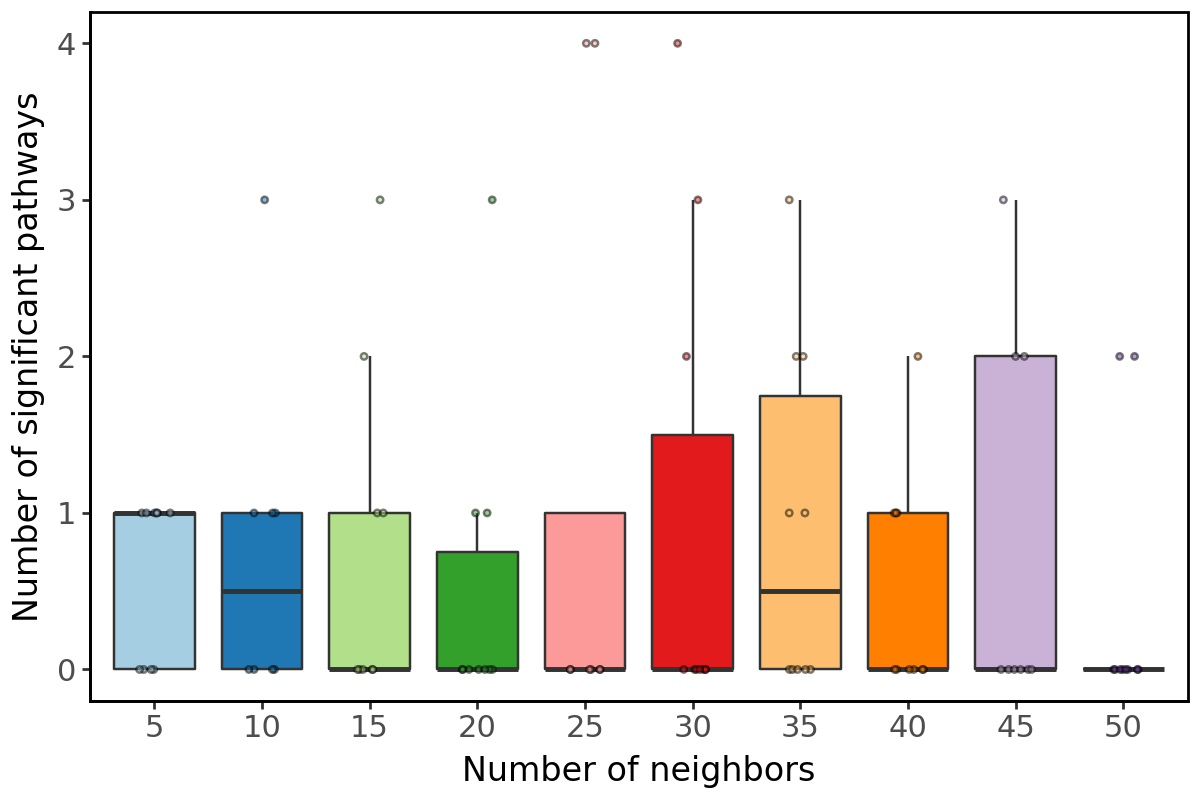

In [13]:
fig = (
ggplot(data=n_sig_pathways_df, mapping=aes(x="n_neighbors", y="Value", fill="n_neighbors")) 
+ geom_boxplot(position=position_dodge(width=0.8), outlier_shape="")
+ geom_jitter(width = 0.15, height=0, size=0.8, alpha=0.5)
+ scale_fill_manual(values=["#A6CEE3", "#1F78B4", "#B2DF8A", "#33A02C", "#FB9A99", "#E31A1C", "#FDBF6F", "#FF7F00", "#CAB2D6", "#6A3D9A"])
+ xlab('Number of neighbors')
+ ylab("Number of significant pathways")
+ theme_classic() 
+ theme(plot_title = element_text(hjust = 0.5,
                                margin={"t": 0, "b": 5, "l": 0, "r": 0},
                                size = 14,
                                face='bold'),
        legend_position = "none",
        axis_title_x = element_text(size = 12),
        axis_title_y = element_text(size = 12),
        axis_text_x = element_text(margin={"t": 4, "b": 0, "l": 10, "r": 0}, size = 11),
        axis_text_y = element_text(margin={"t": 0, "b": 0, "l": 0, "r": 4}, size = 11),
        panel_border = element_rect(color='black'),
        panel_background = element_rect(colour = "black",
                                        linewidth = 1),
        figure_size=(6, 4))
)
fig.save(os.path.join(PLOTS_PATH, 'pairwise_cor_n_sig_pathways_n_neighbors_box_plot.svg'), format='svg')
fig

### Pairwise correlation (min_gene_threshold)

In [14]:
min_gene_threshold_values = [10, 15, 20, 25, 30, 35, 40, 45, 50]

In [15]:
def pairwise_correlation_min_gene_threshold_robustness_pipeline(adata, min_gene_threshold):
    
    harreman.tl.compute_knn_graph(adata,
                           compute_neighbors_on_key="spatial_unrolled",
                           n_neighbors=5,
                           weighted_graph=False,
                           sample_key='cond')
        
    harreman.hs.compute_local_autocorrelation(adata, layer_key="counts", model='danb', species='mouse', use_metabolic_genes=True)
    
    gene_autocorrelation_results = adata.uns['gene_autocorrelation_results']
    genes = gene_autocorrelation_results.loc[gene_autocorrelation_results.Z_FDR < 0.01].sort_values('Z', ascending=False).index
    
    harreman.hs.compute_local_correlation(adata, genes=genes)
    
    harreman.hs.create_modules(adata, min_gene_threshold=min_gene_threshold)
    
    harreman.hs.calculate_module_scores(adata)
    
    modules = adata.obsm['module_scores'].columns
    module_scores_z = pd.DataFrame(zscore(adata.obsm['module_scores']), index=adata.obsm['module_scores'].index, columns=modules)
    morans = {
        m: sc.metrics.morans_i(adata.obsp['weights'], vals=module_scores_z[m])
        for m in modules
    }
    morans_df = pd.Series(morans)
    
    gene_modules = adata.uns['gene_modules']
    
    n_sig_pathways = {}
    for module, genes in gene_modules.items():
        enr_results = Enrichment_analysis_pipeline(kegg_metab, genes, gene_autocorrelation_results.index.tolist())
        enr_results = enr_results[enr_results['Adjusted P-value'] < 0.05].sort_values('Combined Score', ascending=False).copy()
        n_sig_pathways[module] = enr_results.shape[0]
    n_sig_pathways_df = pd.Series(n_sig_pathways)
    
    return morans_df, n_sig_pathways_df

In [16]:
pairwise_correlation_min_gene_threshold_morans_i_dict = {}
pairwise_correlation_min_gene_threshold_n_sig_pathways_dict = {}
for min_gene_threshold in min_gene_threshold_values:
    print(min_gene_threshold)
    morans_df, n_sig_pathways_df = pairwise_correlation_min_gene_threshold_robustness_pipeline(adata, min_gene_threshold)
    pairwise_correlation_min_gene_threshold_morans_i_dict[min_gene_threshold] = morans_df
    pairwise_correlation_min_gene_threshold_n_sig_pathways_dict[min_gene_threshold] = n_sig_pathways_df

10


100%|██████████| 15/15 [00:02<00:00,  7.42it/s]


15


100%|██████████| 12/12 [00:01<00:00,  6.18it/s]


20


...

100%|██████████| 6/6 [00:01<00:00,  3.43it/s]


45


100%|██████████| 5/5 [00:01<00:00,  3.40it/s]


50


100%|██████████| 5/5 [00:01<00:00,  2.92it/s]


In [17]:
morans_df = pd.concat(
    {key: series for key, series in pairwise_correlation_min_gene_threshold_morans_i_dict.items()}, axis=1
).melt( 
    var_name="ngenes", 
    value_name="Value"
).dropna()

n_sig_pathways_df = pd.concat(
    {key: series for key, series in pairwise_correlation_min_gene_threshold_n_sig_pathways_dict.items()}, axis=1
).melt( 
    var_name="ngenes", 
    value_name="Value"
).dropna()

In [18]:
morans_df["ngenes"] = morans_df["ngenes"].astype('category')
n_sig_pathways_df["ngenes"] = n_sig_pathways_df["ngenes"].astype('category')

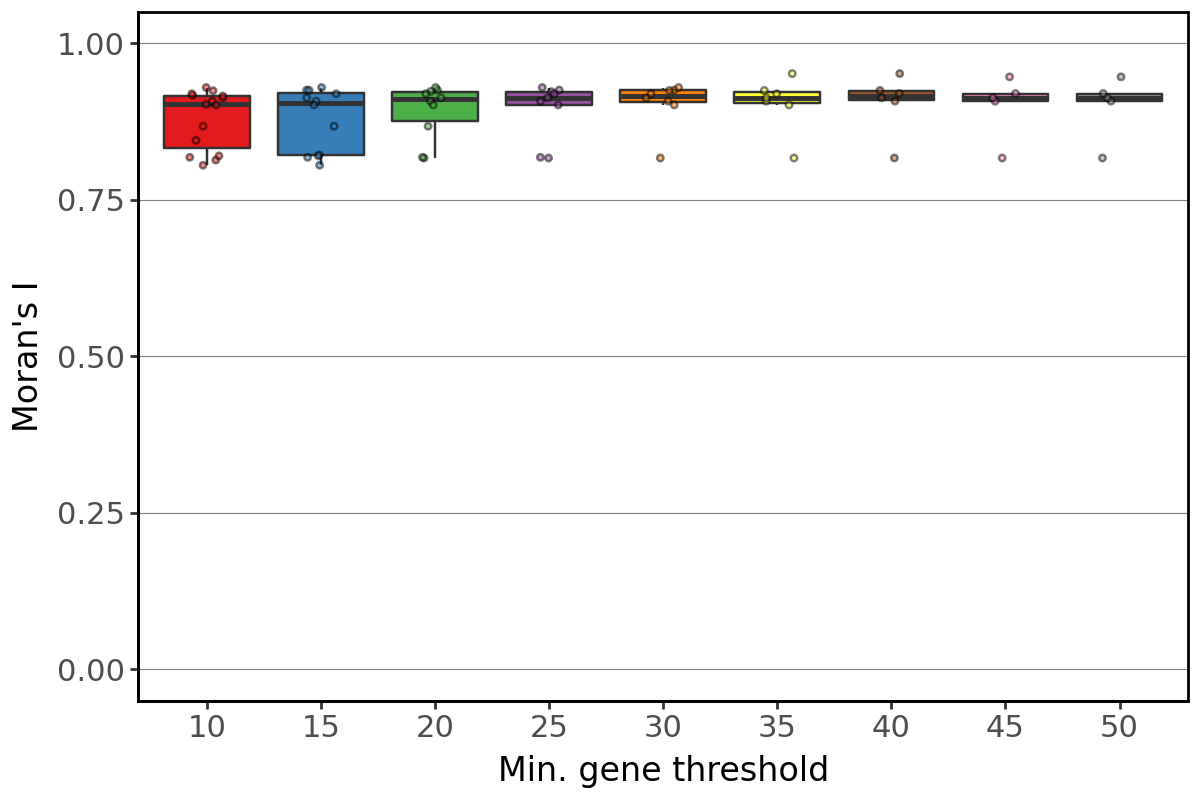

In [19]:
fig = (
ggplot(data=morans_df, mapping=aes(x="ngenes", y="Value", fill="ngenes")) 
+ geom_boxplot(position=position_dodge(width=0.8), outlier_shape="")
+ geom_jitter(width = 0.15, height=0, size=0.8, alpha=0.5)
+ scale_fill_manual(values=["#E41A1C", "#377EB8", "#4DAF4A", "#984EA3", "#FF7F00", "#FFFF33", "#A65628", "#F781BF", "#999999"])
+ xlab('Min. gene threshold')
+ ylab("Moran's I")
+ theme_classic() 
+ scale_y_continuous(
        limits=(0, 1),
        breaks=[0, 0.25, 0.5, 0.75, 1]
)
+ theme(panel_grid_major_y=element_line(color="grey", size=0.4),
        panel_grid_minor_y=element_blank(),
        plot_title = element_text(hjust = 0.5,
                                margin={"t": 0, "b": 5, "l": 0, "r": 0},
                                size = 14,
                                face='bold'),
        legend_position = "none",
        axis_title_x = element_text(size = 12),
        axis_title_y = element_text(size = 12),
        axis_text_x = element_text(margin={"t": 4, "b": 0, "l": 10, "r": 0}, size = 11),
        axis_text_y = element_text(margin={"t": 0, "b": 0, "l": 0, "r": 4}, size = 11),
        panel_border = element_rect(color='black'),
        panel_background = element_rect(colour = "black",
                                        linewidth = 1),
        figure_size=(6, 4))
)
fig.save(os.path.join(PLOTS_PATH, 'pairwise_cor_morans_i_min_gene_box_plot.svg'), format='svg')
fig

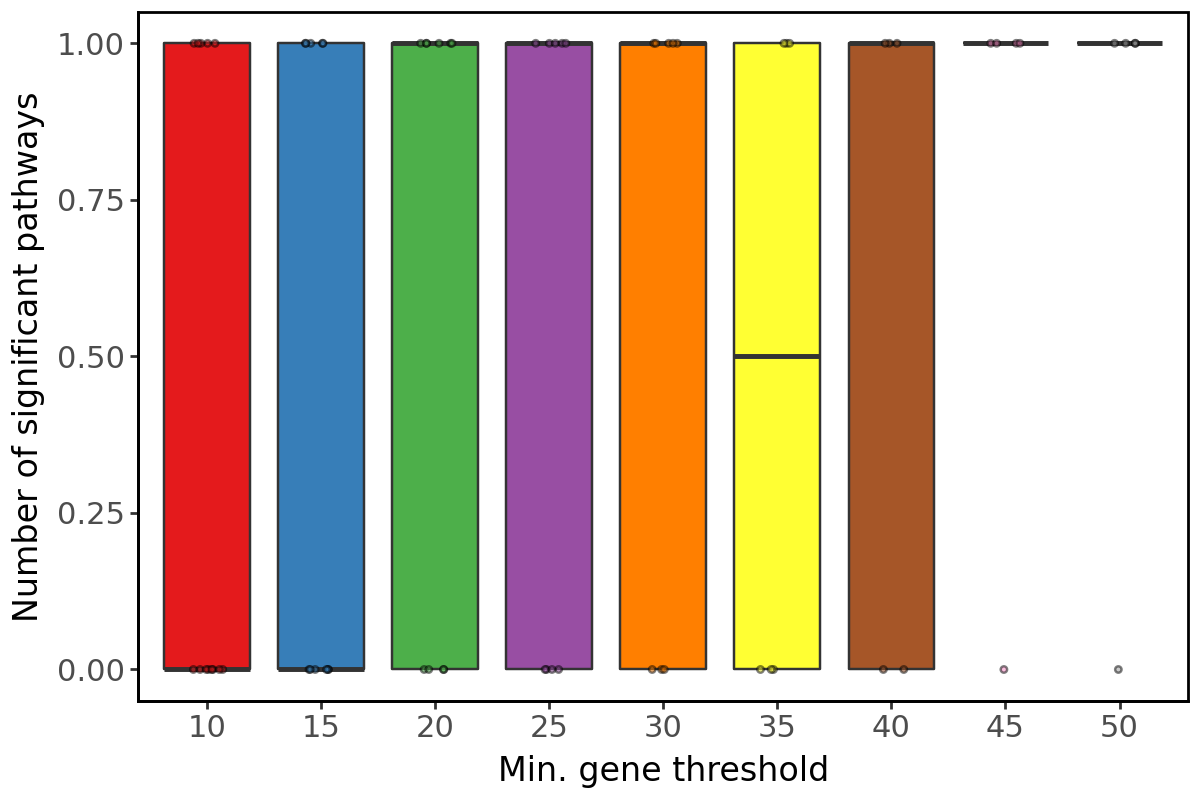

In [20]:
fig = (
ggplot(data=n_sig_pathways_df, mapping=aes(x="ngenes", y="Value", fill="ngenes")) 
+ geom_boxplot(position=position_dodge(width=0.8), outlier_shape="")
+ geom_jitter(width = 0.15, height=0, size=0.8, alpha=0.5)
+ scale_fill_manual(values=["#E41A1C", "#377EB8", "#4DAF4A", "#984EA3", "#FF7F00", "#FFFF33", "#A65628", "#F781BF", "#999999"])
+ xlab('Min. gene threshold')
+ ylab("Number of significant pathways")
+ theme_classic() 
+ ylim(0,1)
+ theme(plot_title = element_text(hjust = 0.5,
                                margin={"t": 0, "b": 5, "l": 0, "r": 0},
                                size = 14,
                                face='bold'),
        legend_position = "none",
        axis_title_x = element_text(size = 12),
        axis_title_y = element_text(size = 12),
        axis_text_x = element_text(margin={"t": 4, "b": 0, "l": 10, "r": 0}, size = 11),
        axis_text_y = element_text(margin={"t": 0, "b": 0, "l": 0, "r": 4}, size = 11),
        panel_border = element_rect(color='black'),
        panel_background = element_rect(colour = "black",
                                        linewidth = 1),
        figure_size=(6, 4))
)
fig.save(os.path.join(PLOTS_PATH, 'pairwise_cor_n_sig_pathways_min_gene_box_plot.svg'), format='svg')
fig